## 1. The Theory & Mathematical Intuition

In Simple Linear Regression, we found a straight line:

$$y = mx + b$$

In Multiple Linear Regression, we don't have just one $x$. We have $x_1, x_2, x_3 \dots x_n$.

Because we have multiple features, our equation expands to:

$$y = b_0 + b_1x_1 + b_2x_2 + \dots + b_nx_n$$

Where:
*   **$y$**: The **Target** (e.g., Placement LPA)
*   **$b_0$**: The **Intercept** (The base LPA if all other features are exactly 0)
*   **$b_1, b_2, \dots$**: The **Coefficients/Weights** (How much does LPA go up for every 1-point increase in CGPA? What about a 1-point increase in Coding Score?)
*   **$x_1, x_2, \dots$**: Your actual data features.

### The Geometric Intuition:

*   With 1 feature, you fit a **1D Line** on a 2D graph.
*   With 2 features, you fit a **2D Plane** (like a flat sheet of paper) inside a 3D room.
*   With 3+ features, you fit a **Hyperplane** in n-dimensional space (impossible for human eyes to see, but the math works exactly the same).

*Play with this interactive 3D widget to physically see what it means to fit a plane through multiple features!*

## 2. Deriving the Formula (The Normal Equation)

When we have 100 features, writing out $y = b_0 + b_1x_1 + \dots$ becomes a nightmare. To solve this mathematically, Data Scientists use Linear Algebra (Matrices).

We can rewrite our entire dataset and equation into a single matrix formula:

$$Y = X\beta$$

Let's break down these matrices:

*   **$Y$**: This is an $(m \times 1)$ column vector of all your target variable observations (the actual values you are trying to predict). For example, if you have $m$ data points, $Y = \begin{pmatrix} y_1 \\ y_2 \\ \vdots \\ y_m \end{pmatrix}$.
*   **$X$**: This is an $(m \times (n+1))$ **design matrix** containing all your feature values. It has $m$ rows (one for each data point) and $n+1$ columns (one for each of your $n$ features, plus an additional column of ones for the intercept term $b_0$).
    $$X = \begin{pmatrix}
    1 & x_{1,1} & x_{1,2} & \dots & x_{1,n} \\
    1 & x_{2,1} & x_{2,2} & \dots & x_{2,n} \\
    \vdots & \vdots & \vdots & \ddots & \vdots \\
    1 & x_{m,1} & x_{m,2} & \dots & x_{m,n}
    \end{pmatrix}$$
*   **$\beta$**: This is an $((n+1) \times 1)$ column vector of all your optimal **weights (coefficients)**, including the intercept term. $\beta = \begin{pmatrix} b_0 \\ b_1 \\ \vdots \\ b_n \end{pmatrix}$.

### The Objective (Loss Function):

Just like in 2D, we want to minimize the squared errors. In matrix notation, squaring the error $(Y - X\beta)$ looks like this:

$$L = (Y - X\beta)^T(Y - X\beta)$$

**Understanding the Loss Function (Mean Squared Error - MSE):**

This function is often referred to as the **Sum of Squared Residuals (SSR)** or a scaled version of the **Mean Squared Error (MSE)**. Its purpose is to quantify how well our linear model fits the observed data. The term $(Y - X\beta)$ represents the vector of residuals (the difference between the actual target values and the values predicted by our model). By squaring these differences and summing them up, we achieve a few key benefits:

1.  **Penalizes large errors more heavily**: Squaring ensures that larger errors contribute disproportionately more to the total loss, pushing the model to reduce them.
2.  **Non-negative values**: All squared errors are positive, so they don't cancel each other out, giving a true measure of total error.
3.  **Differentiability**: The squared error function is continuous and differentiable, which is crucial for using calculus to find the minimum point (as seen in the derivation below).
4.  **Convexity**: For linear regression, the MSE loss function is convex, meaning it has a single global minimum, making it easier to optimize.

### The Derivation:

To find the exact bottom of this error bowl, we take the derivative with respect to our weights ($\beta$) and set it to exactly 0.

Expand the equation:

$$L = Y^TY - Y^TX\beta - \beta^TX^TY + \beta^TX^TX\beta$$

Take the derivative $\frac{\partial L}{\partial \beta}$ and set it to 0:

$$-2X^TY + 2X^TX\beta = 0$$

Move the terms to opposite sides:

$$X^TX\beta = X^TY$$

Isolate $\beta$ (The Final Formula): To get $\beta$ alone, we multiply both sides by the inverse of $(X^TX)$:

$$\beta = (X^TX)^{-1}X^TY$$

This is called the **Normal Equation**. It is the exact mathematical engine inside Scikit-Learn's `LinearRegression` algorithm when dealing with multiple columns!

## 3. A Numerical Example

Let's plug some numbers into our brain to see how the final model thinks.

Assume we ran the Normal Equation matrix math on our student dataset, and the algorithm handed us these weights ($\beta$):

*   $b_0$ (Intercept) = 2.0
*   $b_1$ (CGPA Weight) = 1.5
*   $b_2$ (Coding Score Weight) = 0.1

Our equation is:

$$\text{LPA} = 2.0 + (1.5 \times \text{CGPA}) + (0.1 \times \text{Coding})$$

Scenario: A student comes to you with an 8.0 CGPA and an 80 Coding Score. What is their predicted placement?

$\text{LPA} = 2.0 + (1.5 \times 8.0) + (0.1 \times 80)$

$\text{LPA} = 2.0 + 12.0 + 8.0$

**Predicted LPA = 22 Lakhs**

Notice how the model combines the "pull" of both features to arrive at the final number.

# 4. 3D Visualization Code
You cannot visualize 10 features, but you can visualize 2 features. Let's write the exact Python code to generate a 3D dataset, train the Scikit-Learn algorithm, and plot the 2D regression plane cutting perfectly through the 3D data.

--- The Normal Equation Results ---
Intercept (b0): 2.38
CGPA Weight (b1): 1.50
Coding Weight (b2): 0.09


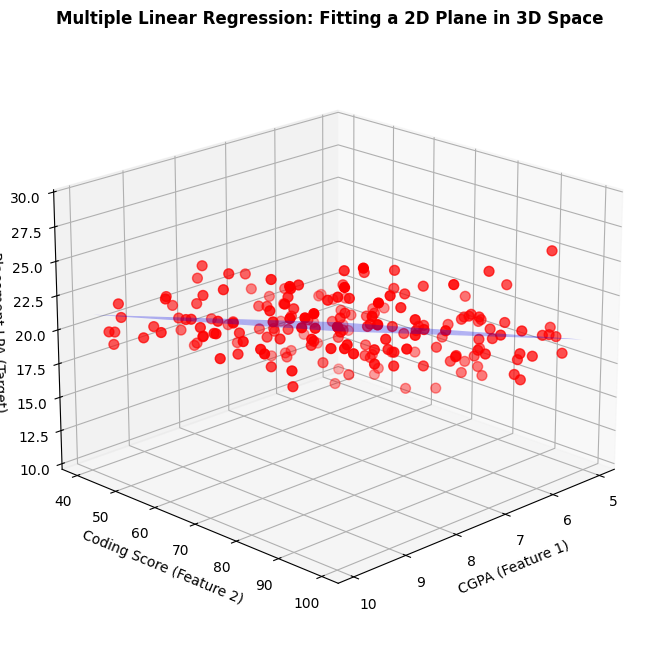

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error


# 1. CREATE DUMMY DATA (2 Features, 1 Target)
np.random.seed(42)

# Feature 1: CGPA (0 to 10)
cgpa = np.random.uniform(5, 10, 200)

# Feature 2: Coding Score (0 to 100)
coding = np.random.uniform(40, 100, 200)

# Target: LPA (Depends on both, plus noise)
# Perfect Equation: LPA = 2 + (1.5 * CGPA) + (0.1 * Coding)
noise = np.random.normal(0, 2, 200)
lpa = 2 + (1.5 * cgpa) + (0.1 * coding) + noise

df = pd.DataFrame({'CGPA': cgpa, 'Coding': coding, 'LPA': lpa})

X = df[['CGPA', 'Coding']]
y = df['LPA']


# 2. TRAIN THE MODEL
model = LinearRegression()
model.fit(X, y)

print("--- The Normal Equation Results ---")
print(f"Intercept (b0): {model.intercept_:.2f}")
print(f"CGPA Weight (b1): {model.coef_[0]:.2f}")
print(f"Coding Weight (b2): {model.coef_[1]:.2f}")

# 3. CREATE THE 3D VISUALIZATION
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot the actual data points
ax.scatter(df['CGPA'], df['Coding'], df['LPA'], color='red', s=50, label='Actual Students')

# Create a meshgrid to plot the plane
# We take the min and max of both features to draw a flat sheet across the whole space
x_surf, y_surf = np.meshgrid(
    np.linspace(df['CGPA'].min(), df['CGPA'].max(), 10),
    np.linspace(df['Coding'].min(), df['Coding'].max(), 10)
)

# Predict the Z values (LPA) for every point on that flat sheet
# We flatten the meshgrid, predict, and then reshape it back to a grid
core_features = pd.DataFrame({'CGPA': x_surf.flatten(), 'Coding': y_surf.flatten()})
z_surf = model.predict(core_features).reshape(x_surf.shape)

# Plot the translucent regression plane
ax.plot_surface(x_surf, y_surf, z_surf, color='blue', alpha=0.3)

ax.set_title('Multiple Linear Regression: Fitting a 2D Plane in 3D Space', fontweight='bold')
ax.set_xlabel('CGPA (Feature 1)')
ax.set_ylabel('Coding Score (Feature 2)')
ax.set_zlabel('Placement LPA (Target)')
ax.view_init(elev=20, azim=45) # Adjust viewing angle

plt.show()